In [33]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/student_data.csv")
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [25]:
# Convert Grade Columns to list
G3_list = df['G3'].tolist()
studytime_list = df['studytime'].tolist()

n = len(G3_list)
print(n)

395


Calculating the Mean of the Final Grade and the Study_time

In [27]:
## Mean of the Final Grade
mean_G3 = sum(G3_list) / n
### Mean of the StudyTime
mean_studytime = sum(studytime_list) / n

print("Mean G3:", mean_G3)
print("Mean studytime:", mean_studytime)

Mean G3: 10.415189873417722
Mean studytime: 2.0354430379746837


Calculating covariance using Formula

In [28]:
cov_sum = 0

for i in range(n):
    cov_sum += (G3_list[i] - mean_G3) * (studytime_list[i] - mean_studytime)

covariance = cov_sum / (n - 1)
print("Covariance:", covariance)

Covariance: 0.3761100044978472


Calculating standard deviations using the formula

In [29]:
# For G3
std_G3_sum = 0
for i in range(n):
    std_G3_sum += (G3_list[i] - mean_G3)**2
std_G3 = (std_G3_sum / (n - 1))**0.5

# For studytime
std_study_sum = 0
for i in range(n):
    std_study_sum += (studytime_list[i] - mean_studytime)**2
std_study = (std_study_sum / (n - 1))**0.5

print("Std G3:", std_G3)
print("Std studytime:", std_study)

Std G3: 4.5814426109978434
Std studytime: 0.839240346418556


Calculating correlation between them

In [30]:
correlation = covariance / (std_G3 * std_study)
print("Correlation between G3 and studytime:", correlation)

Correlation between G3 and studytime: 0.09781968965319618


Conclusion ::

Correlation between G3 and studytime: 0.0978. There is a small positive relationship, meaning students who study a little more tend to perform slightly better

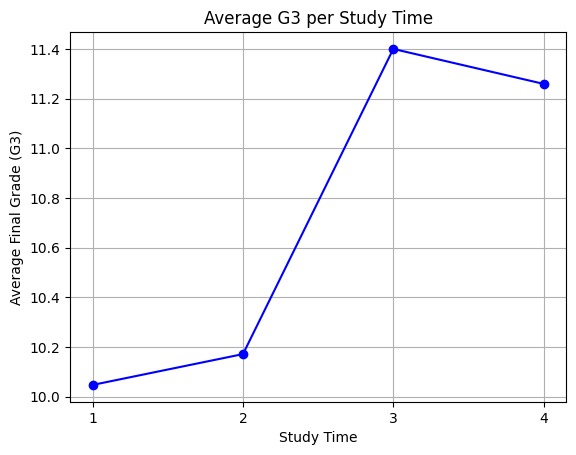

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average G3 per studytime
avg_grade = df.groupby('studytime')['G3'].mean().reset_index()

# Line plot
plt.plot(avg_grade['studytime'], avg_grade['G3'], marker='o', color='blue')
plt.title('Average G3 per Study Time')
plt.xlabel('Study Time')
plt.ylabel('Average Final Grade (G3)')
plt.xticks([1,2,3,4])
plt.grid(True)
## For Saving the Image's
plt.savefig('average_g3_per_studytime.png', dpi=300, bbox_inches='tight')
plt.show()

Conclusion ::
As study time increases, the average final grade (G3) generally rises, indicating that students who study more tend to perform slightly better.